In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

# 读取原始 CSV
df = pd.read_csv("/content/google_combined_review.csv")

# 1. 提取年份（假设你的日期字段叫 datetaken，如果不是请改）
df["datetaken"] = pd.to_datetime(df["date_taken"], errors="coerce")
df["year"] = df["datetaken"].dt.year

# 2. 删除 2024 年以前的数据
df_filtered = df[df["year"] >= 2024]

# 3. 保存为新的 CSV
df_filtered.to_csv("flickr_data_filtered_2024_2025.csv", index=False)

print("完成！生成文件：flickr_data_filtered_2024_2025.csv")


KeyError: 'date_taken'

In [ ]:
import ast
import numpy as np
import pandas as pd
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
import folium
from folium.plugins import HeatMap

# ========= 配置区域 ==========
CSV_PATH = "/content/google_combined_review.csv"
OUTPUT_CSV = "1q1.csv"
OUTPUT_HTML = "Googlemap_sentiment_heatmap.html"

TEXT_COL = "review"
# 根据 DataFrame 的列名，GPS 坐标列名为 'gps'
GPS_COL = "gps"

# ========= 1. 读取 & 解析坐标 ==========
print("▶ 读取 CSV...")
df = pd.read_csv(CSV_PATH)

# --- 临时添加：打印所有列名以调试 ---
print("DataFrame 中所有列名:", df.columns.tolist())
# -------------------------------------

def parse_gps(gps_str):
    if pd.isna(gps_str):
        return np.nan, np.nan
    try:
        # GPS 列可能直接是字符串形式的字典或嵌套结构
        d = ast.literal_eval(str(gps_str))
        # 尝试从字典中提取 latitude 和 longitude
        return d.get("latitude"), d.get("longitude")
    except (ValueError, SyntaxError, TypeError): # 捕获更多的解析错误
        # 如果直接是 "lat,lng" 格式，尝试分割
        if isinstance(gps_str, str) and ',' in gps_str:
            parts = gps_str.split(',')
            if len(parts) == 2:
                try:
                    return float(parts[0].strip()), float(parts[1].strip())
                except ValueError:
                    return np.nan, np.nan
        return np.nan, np.nan

print("▶ 解析 lat/lng...")
df[["lat", "lng"]] = df[GPS_COL].apply(lambda x: pd.Series(parse_gps(x)))

df = df.dropna(subset=[TEXT_COL, "lat", "lng"])
df["lat"] = pd.to_numeric(df["lat"], errors="coerce")
df["lng"] = pd.to_numeric(df["lng"], errors="coerce")
df = df.dropna(subset=["lat", "lng"])

# ========= 2. 情绪分析：TextBlob + VADER ==========
print("▶ 下载 VADER 词典（第一次需要）...")
nltk.download("vader_lexicon")

sia = SentimentIntensityAnalyzer()

def sentiment_textblob(text):
    tb = TextBlob(text)
    return tb.polarity, tb.subjectivity

def sentiment_vader(text):
    return sia.polarity_scores(text)

polarities = []
subjectivities = []
vaders = []

print("▶ 计算情绪分数（TextBlob + VADER）...")
for text in df[TEXT_COL]:
    if isinstance(text, str) and text.strip():
        pol, sub = sentiment_textblob(text)
        polarities.append(pol)
        subjectivities.append(sub)
        vaders.append(sentiment_vader(text))
    else:
        polarities.append(np.nan)
        subjectivities.append(np.nan)
        vaders.append({"neg": np.nan, "neu": np.nan, "pos": np.nan, "compound": np.nan})

df["polarity"] = polarities
df["subjectivity"] = subjectivities
df["vader_neg"] = [v["neg"] for v in vaders]
df["vader_neu"] = [v["neu"] for v in vaders]
df["vader_pos"] = [v["pos"] for v in vaders]
df["compound"] = [v["compound"] for v in vaders]

# 生成热力图用的 0~1 权重（把 -1~1 映射到 0~1）
df["sentiment_norm"] = (df["compound"] + 1) / 2

print(df[[TEXT_COL, "polarity", "subjectivity", "compound"]].head())

# 保存
df.to_csv(OUTPUT_CSV, index=False, encoding="utf-8-sig")
print(f"✅ 带情绪结果的 CSV 已保存：{OUTPUT_CSV}")

# ========= 3. Sentiment Heatmap（使用 compound） ==========
print("▶ 生成情绪热力图...")

center_lat = df["lat"].mean()
center_lng = df["lng"].mean()

m = folium.Map(location=[center_lat, center_lng], zoom_start=13, tiles="OpenStreetMap")

heat_data = df[["lat", "lng", "sentiment_norm"]].values.tolist()

HeatMap(
    heat_data,
    radius=13,
    blur=18,
    min_opacity=0.3,
).add_to(m)

m.save(OUTPUT_HTML)
print(f"✅ 情绪热力图已生成：{OUTPUT_HTML}")


▶ 读取 CSV...
DataFrame 中所有列名: ['place_id', 'place_title', 'gps', 'rating', 'date', 'title', 'name', 'review', 'images', 'likes', 'local_guide']
▶ 解析 lat/lng...
▶ 下载 VADER 词典（第一次需要）...
▶ 计算情绪分数（TextBlob + VADER）...


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


                                              review  polarity  subjectivity  \
0  One the one hand some of the pharmacists were ...   0.15000      0.750000   
1  Very friendly and helpful staff - went on look...   0.24244      0.503452   
2  Staff were very helpful in arranging for me to...   0.35000      0.511111   
3  Extremely rude service. The person  behind the...  -0.20625      0.418750   
4      Very well organized,  very professional staff   0.16500      0.215000   

   compound  
0    0.2128  
1    0.9555  
2    0.8399  
3   -0.5095  
4    0.3384  
✅ 带情绪结果的 CSV 已保存：1q1.csv
▶ 生成情绪热力图...
✅ 情绪热力图已生成：Googlemap_sentiment_heatmap.html


生成柱状图或折线图

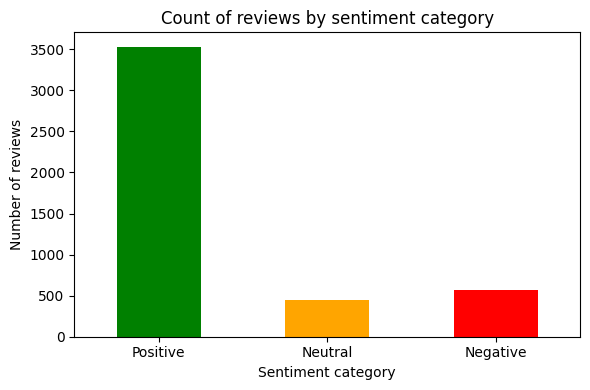

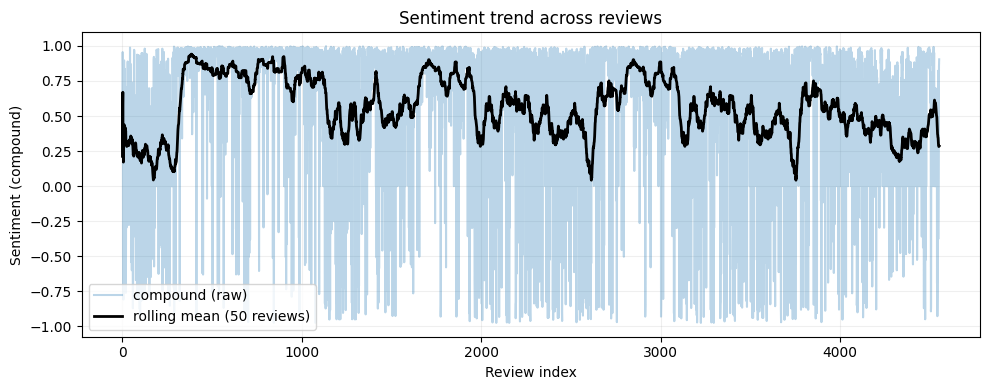

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ========= 配置：你的情绪结果 CSV 文件名 =========
CSV_PATH = "1q1.csv"  # 修正为情绪分析结果文件

# ========= 1. 读取数据 =========
df = pd.read_csv(CSV_PATH)

# 确保有 compound 列
if "compound" not in df.columns:
    raise ValueError("CSV 中没有 'compound' 列，请确认上一段情绪分析代码是否正确运行。")

# 丢掉没有情绪值的行
df = df.dropna(subset=["compound"])

# ========= 2. 定义情绪类别：正 / 中 / 负 =========
def label_sentiment(c, pos_th=0.2, neg_th=-0.2):
    if c >= pos_th:
        return "Positive"
    elif c <= neg_th:
        return "Negative"
    else:
        return "Neutral"

df["sentiment_cat"] = df["compound"].apply(label_sentiment)

# ========= 3. 柱状图：各类情绪数量 =========
sent_counts = df["sentiment_cat"].value_counts().reindex(["Positive", "Neutral", "Negative"])

plt.figure(figsize=(6, 4))
sent_counts.plot(kind="bar", color=["green", "orange", "red"])
plt.xlabel("Sentiment category")
plt.ylabel("Number of reviews")
plt.title("Count of reviews by sentiment category")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# ========= 4. 折线图：按索引的情绪趋势（简单版） =========
# 如果你之后有“时间列”，可以按时间排序；现在先按原始顺序看整体波动
df_sorted = df.reset_index(drop=True).copy()
df_sorted["rolling_mean"] = df_sorted["compound"].rolling(window=50, min_periods=1).mean()
# 这里 window=50 表示每 50 条评论做一次平滑，你可以自己改大/改小

plt.figure(figsize=(10, 4))
plt.plot(df_sorted.index, df_sorted["compound"], alpha=0.3, label="compound (raw)")
plt.plot(df_sorted.index, df_sorted["rolling_mean"], color="black", linewidth=2, label="rolling mean (50 reviews)")
plt.xlabel("Review index")
plt.ylabel("Sentiment (compound)")
plt.title("Sentiment trend across reviews")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


Heatmap

In [ ]:
import pandas as pd
import folium
from folium.plugins import HeatMap

# ========= 配置：同一个情绪 CSV =========
CSV_PATH = "1q1.csv" # 修正为情绪分析结果文件
OUTPUT_HTML = "osm_sentiment_heatmap.html"

# ========= 1. 读取数据 =========
df = pd.read_csv(CSV_PATH)

# 确保有 lat, lng, sentiment_norm
for col in ["lat", "lng", "sentiment_norm"]:
    if col not in df.columns:
        raise ValueError(f"CSV 中缺少列: {col}")

# 丢掉缺失值
df = df.dropna(subset=["lat", "lng", "sentiment_norm"])

# ========= 2. 设置地图中心 =========
center_lat = df["lat"].mean()
center_lng = df["lng"].mean()

# tiles='OpenStreetMap' 就是 OSM 底图
m = folium.Map(
    location=[center_lat, center_lng],
    zoom_start=13,
    tiles="OpenStreetMap"
)

# ========= 3. 构造 HeatMap 数据 =========
# [lat, lng, weight]，这里 weight 用 sentiment_norm（0~1，越接近1越正面）
heat_data = df[["lat", "lng", "sentiment_norm"]].values.tolist()

HeatMap(
    heat_data,
    radius=13,       # 扩散半径，可调大/调小
    blur=18,         # 模糊程度
    min_opacity=0.3  # 最低透明度
).add_to(m)

m.save(OUTPUT_HTML)
print(f"✅ 已生成 OSM 情绪热力图：{OUTPUT_HTML}")
print("用浏览器打开这个 HTML 文件就可以查看。")

✅ 已生成 OSM 情绪热力图：osm_sentiment_heatmap.html
用浏览器打开这个 HTML 文件就可以查看。


In [ ]:
import pandas as pd
import folium

# 应该读取包含 'compound' 列的 CSV 文件
CSV_PATH = "/content/1q1.csv" # 修正：从生成的1q1.csv文件读取
OUTPUT_HTML = "osm_sentiment_scatterpoints.html"

# 1. 读取数据
df = pd.read_csv(CSV_PATH)
df = df.dropna(subset=["lat", "lng", "compound"])

# 颜色映射函数（红→黄→绿）
def sentiment_color(c):
    if c >= 0.2:
        return "green"
    elif c <= -0.2:
        return "red"
    else:
        return "orange"

# 2. 地图中心
center_lat = df["lat"].mean()
center_lng = df["lng"].mean()

m = folium.Map(
    location=[center_lat, center_lng],
    zoom_start=13,
    tiles="OpenStreetMap"
)

# 3. 加散点
for _, row in df.iterrows():
    color = sentiment_color(row["compound"])
    popup_text = f"Sentiment: {row['compound']:.3f}"

    folium.CircleMarker(
        location=[row["lat"], row["lng"]],
        radius=4,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.7,
        popup=popup_text
    ).add_to(m)

m.save(OUTPUT_HTML)
print(f"✔ 散点地图已保存到：{OUTPUT_HTML}")


✔ 散点地图已保存到：osm_sentiment_scatterpoints.html


In [ ]:
import geopandas as gpd
from shapely.geometry import Point
import os # Import the os module

df['geometry'] = df.apply(lambda row: Point(row['lng'], row['lat']), axis=1)
gdf = gpd.GeoDataFrame(df, geometry='geometry', crs="EPSG:4326")

output_dir = "11"
output_file_path = os.path.join(output_dir, "venice_points.geojson")

# Create the directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

gdf.to_file(output_file_path, driver="GeoJSON")